<a href="https://colab.research.google.com/github/TAMIDSpiyalong/Advanced-Concepts-in-Machine-Learning-for-Energy/blob/main/Lecture_3a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab: Object Tracking

With bounding box detections, object tracking involves assigning the same ID to objects across consecutive frames, allowing us to follow their movements over time. One popular method for object tracking is the Simple Online and Real-time Tracking (SORT) algorithm, which can be installed using the pip package manager. The original research paper for SORT can be found at https://arxiv.org/abs/1602.00763.

SORT is a real-time tracking algorithm that efficiently handles multiple objects and maintains their identities over time. It combines the Kalman filter for object state prediction and the Hungarian algorithm for data association to match detections in consecutive frames. This allows it to accurately track objects even in complex scenarios with occlusions and appearance changes.

In [ ]:
import math

from PIL import Image
import requests
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

import ipywidgets as widgets
from IPython.display import display, clear_output

import torch
from torch import nn
from torchvision.models import resnet50
import torchvision.transforms as T
torch.set_grad_enabled(False);

In [ ]:
# standard PyTorch mean-std input image normalization
transform = T.Compose([
    T.Resize(800),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# for output bounding box post-processing
def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)


def rescale_bboxes(out_bbox, size):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox).cpu()
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32)
    return b

In [ ]:
# COCO classes
CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

# colors for visualization
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

In [ ]:
! pip -q install motrackers

## Traffic Speed from Cameras

One example application is to measure lane-specific individual vehicle speed using existing traffic monitoring cameras and computers. The method is reliable and cost-effective, supporting detailed safety analysis for traffic speed monitoring and traffic management. More details are here https://www.tandfonline.com/doi/full/10.1080/15389588.2023.2173522.

At TAMIDS, we also appliy this system to understand the fighting Texas Aggie Football Team home game traffic. The traffic count and speed can show conjestion and flow speed on a real-time map, valuable information to get around. You can find details here https://link.springer.com/article/10.1007/s43762-021-00031-w.


## Download Data

Let's first download a free-to-use example video, 10 seconds long. Colab is not easy to work with videos, especially displaying it. You do not have to worry about it on your local machine.

In [ ]:
from IPython.display import HTML
from base64 import b64encode
video_path = 'Cars moving on road Stock Footage - Free Download.mp4'

mp4 = open(video_path,'rb').read()
decoded_vid = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f'<video width=800 controls><source src={decoded_vid} type="video/mp4"></video>')

## GPU

We need to push the model to GPU now because the video is large and we are taking the input of 800*800 pixel. You can change it in `Runtime`->`change runtime type`->`GPU`. Try CPU and GPU to see the difference.

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [ ]:
model = torch.hub.load('facebookresearch/detr', 'detr_resnet50', pretrained=True)

model.to(device)
model.eval();

Using cache found in /root/.cache/torch/hub/facebookresearch_detr_main


## Make Prediction Function

When we define the prediction function, we are only interested in cars and trucks which are class number 3 and 8, and we ignore the rest. We also set the confidence threhold to 0.5.

In [ ]:
def predict(im):
    img = transform(im).unsqueeze(0).to(device)
    # propagate through the model
    outputs = model(img)

    # keep only predictions with 0.5+ confidence
    probas = outputs['pred_logits'].softmax(-1)[0, :, :-1]
    keep = probas.max(-1).values > 0.5

    # convert boxes from [0; 1] to image scales
    bboxes_scaled = rescale_bboxes(outputs['pred_boxes'][0, keep], im.size)

    pil_img, prob, boxes=im, probas[keep], bboxes_scaled
    # print(prob)

    colors = COLORS * 100
    confs=[]
    bboxes=[]
    classes=[]
    for p, (xmin, ymin, xmax, ymax), c in zip(prob, boxes.tolist(), colors):

        cl = p.argmax()
        if cl not in [3,8]:
            continue

        text = f'{CLASSES[cl]}: {p[cl]:0.2f}'

        confs.append(p[p.argmax()].detach().cpu().numpy())
        bboxes.append([xmin, ymin, xmax, ymax])
        classes.append(cl.detach().cpu().numpy())

    return [confs,bboxes,classes]

### Two Frame Example

Randomly select frame 150 and 151 to make predictions and then apply Hungarian algorithm to match boxes in two seperate frames.  There is a useful online Hungarian matching calculator, check it out. https://www.hungarianalgorithm.com/solve.php

In [ ]:
import cv2

cap = cv2.VideoCapture('Cars moving on road Stock Footage - Free Download.mp4')
frame1=frame2=None

frame_number=0
while True:
    frame_number+=1
    ret, frame = cap.read()  # frame shape 640*480*3
    if ret != True:
        break
    if frame_number==150:
        frame1=frame.copy()

    if frame_number==151:
        frame2=frame.copy()

Showing frame1 and frame2 with prediction boxes with confidences. We will use the boxes to assign IDs.

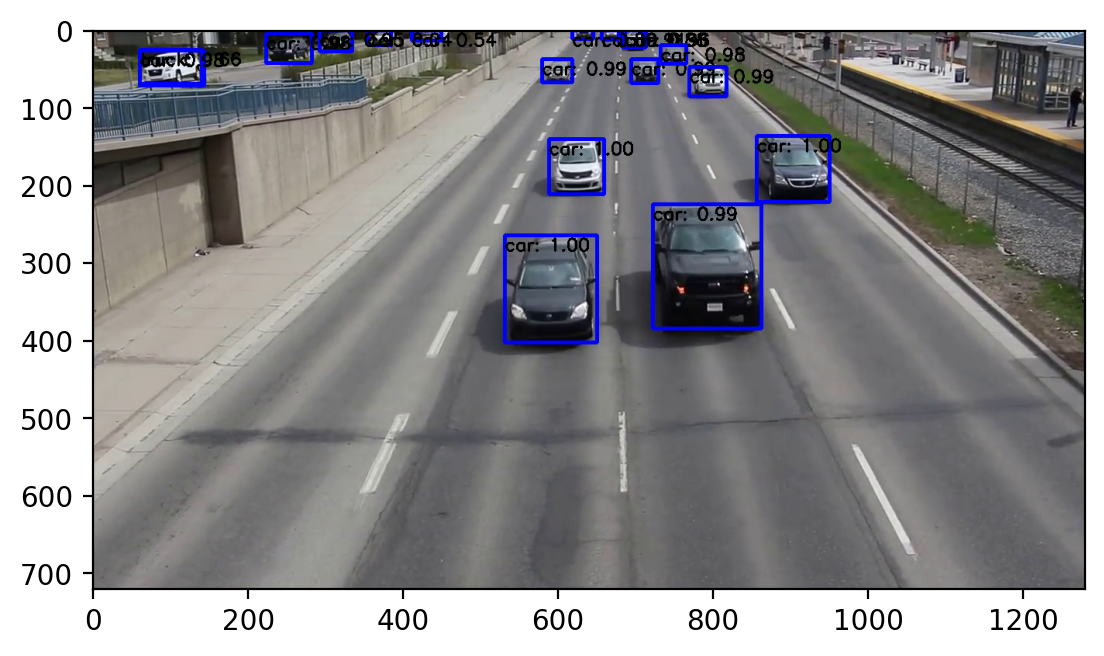

In [ ]:
frame=frame1
img_raw = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
img_raw = Image.fromarray(img_raw)
# run inference
detection_confidences ,bboxes_scaled , detection_class_ids = predict(img_raw)
boxes1=bboxes_scaled
for c,bbox,cl in zip(detection_confidences ,bboxes_scaled , detection_class_ids):
    # print(bbox)
    x1,y1,x2,y2 = bbox
    cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (255,0,0), 3)
    text = f'{CLASSES[cl]}: {c:0.2f}'
    cv2.putText(frame,text,(int(x1), int(y1+20)), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0,0,0), 2)
plt.imshow(frame[:,:,::-1])

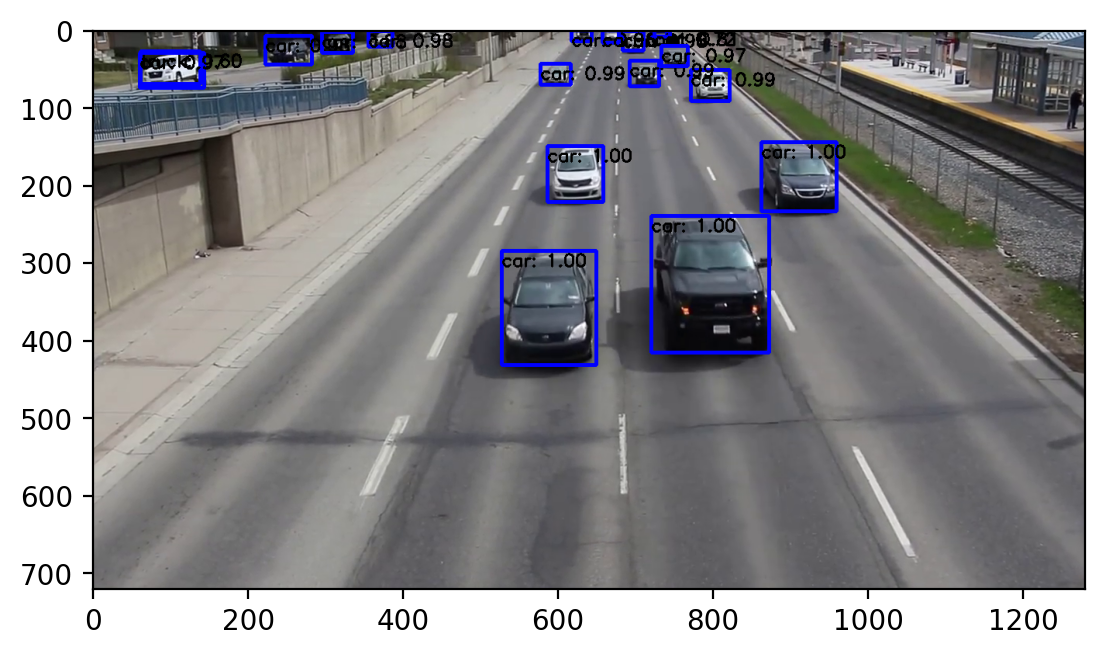

In [ ]:
frame=frame2
img_raw = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
img_raw = Image.fromarray(img_raw)
# run inference
detection_confidences ,bboxes_scaled , detection_class_ids = predict(img_raw)
boxes2=bboxes_scaled
for c,bbox,cl in zip(detection_confidences ,bboxes_scaled , detection_class_ids):
    # print(bbox)
    x1,y1,x2,y2 = bbox
    cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (255,0,0), 3)
    text = f'{CLASSES[cl]}: {c:0.2f}'
    cv2.putText(frame,text,(int(x1), int(y1+20)), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0,0,0), 2)
plt.imshow(frame[:,:,::-1])

In [ ]:
frame.shape

(720, 1280, 3)

Becuase these two frame are not the same, we plot all the boxes on a blank canvas to show the comparison. Each list of boxes is assigned a list of ID: numbers and letters. Here, we assume the numbered boxes are in the first frame and the following frame has lettered boxes.

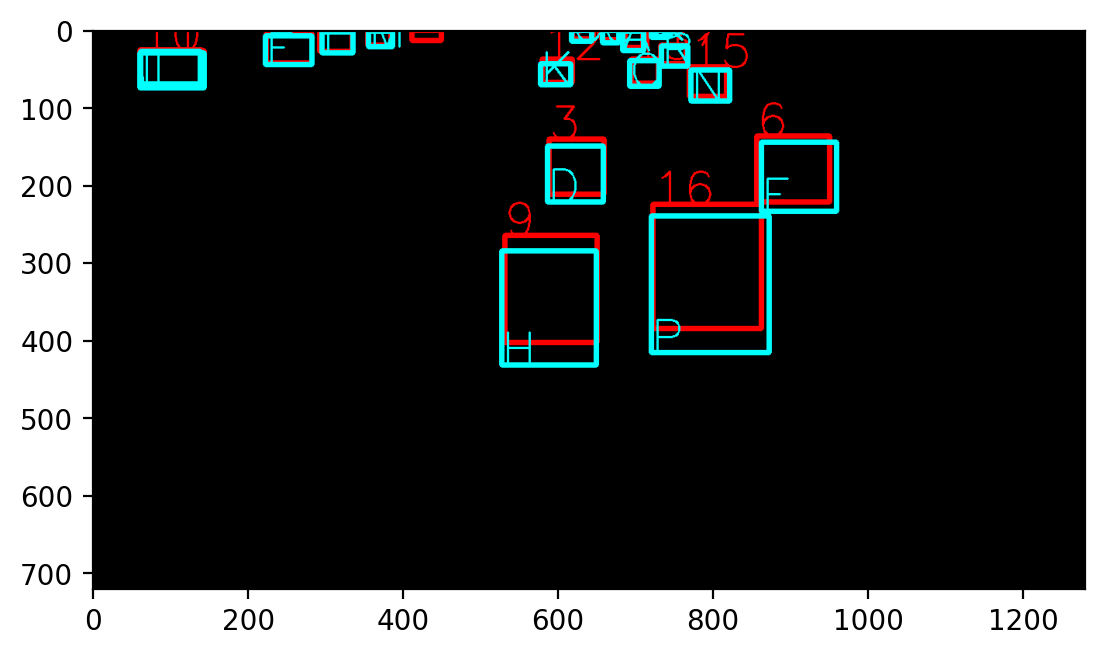

In [ ]:
import cv2
import numpy as np
import string
alphabet = list(string.ascii_uppercase)

def plot_boxes_on_blank_canvas(boxes_list1, boxes_list2, canvas_size=(frame.shape[0], frame.shape[1]), color1=(255, 0, 0), color2=(0, 255, 255)):
    # Create a blank canvas as a NumPy array
    canvas = np.zeros((canvas_size[0], canvas_size[1], 3), dtype=np.uint8)  # Black canvas

    # Draw boxes from the first list with color1
    for i,bbox in enumerate(boxes_list1):

        x1,y1,x2,y2 = bbox
        cv2.rectangle(canvas, (int(x1), int(y1)), (int(x2), int(y2)), color1, thickness=5)
        cv2.putText(canvas,str(i),(int(x1), int(y1)), cv2.FONT_HERSHEY_SIMPLEX, 2, color1, 2)
    # Draw boxes from the second list with color2
    for i,bbox in enumerate(boxes_list2):
        x1,y1,x2,y2 = bbox
        cv2.rectangle(canvas, (int(x1), int(y1)), (int(x2), int(y2)), color2, thickness=5)
        cv2.putText(canvas,alphabet[i],(int(x1), int(y2)), cv2.FONT_HERSHEY_SIMPLEX, 2, color2, 2)
    # Show the canvas with the plotted boxes
    plt.imshow(canvas)

# Example usage
# boxes_list1 = [[10, 20, 40, 50], [60, 30, 80, 70]]
# boxes_list2 = [[25, 35, 50, 60], [70, 40, 90, 80]]
# plot_boxes_on_blank_canvas(boxes_list1, boxes_list2)
plot_boxes_on_blank_canvas(boxes1, boxes2)


We can see just in two frames, the cars move considerable distance. For the best tracking results, we should not skip frames. Human eyes do not necessarily catch this difference.

Next, we calculate the IoU for all possible pair for all boxes, resulting in a cost matrix. Note here IoU = 1 means the best result and 0 means no overlap. We want the opposite case to build the cost matrix so we can minimize the cost.

In [ ]:
import numpy as np

def calculate_iou(box1, box2):
    # Calculate the intersection area
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    intersection_area = max(0, x_right - x_left) * max(0, y_bottom - y_top)

    # Calculate the union area
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - intersection_area

    # Calculate the IOU
    iou = intersection_area / union_area
    return iou

def compute_cost_matrix(boxes_list1, boxes_list2):
    cost_matrix = np.zeros((len(boxes_list1), len(boxes_list2)))

    for i, box1 in enumerate(boxes_list1):
        for j, box2 in enumerate(boxes_list2):
            cost_matrix[i, j] = 1 - calculate_iou(box1, box2)

    return cost_matrix

# Example usage
# boxes_list1 = [[10, 20, 40, 50], [60, 30, 80, 70]]
# boxes_list2 = [[25, 35, 50, 60], [70, 40, 90, 80]]
cost_matrix = compute_cost_matrix(boxes1, boxes2)


In [ ]:
len(boxes1)

18

Putting the cost matrix in a panda frame to see better.

In [ ]:
import pandas as pd
pd.DataFrame(cost_matrix)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0.242275,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
1,0.373442,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
2,1.000000,1.0,0.282584,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
3,1.000000,1.0,1.000000,0.255912,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
4,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.226665,1.000000,1.000000,1.000000,1.0,1.000000
5,1.000000,1.0,1.000000,1.000000,0.129629,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
6,1.000000,1.0,1.000000,1.000000,1.000000,0.318174,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
7,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,0.326132,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
8,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.220407,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
9,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,0.318142,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


## Hungarian Matching

Here function `linear_sum_assignment` returns the row and column index with the lowest cost one-on-one matching. We can print out the results and see if they actually match the correct boxes. Go back and look at the visualization and verify.

In [ ]:
from scipy.optimize import linear_sum_assignment

row_indices, col_indices = linear_sum_assignment(cost_matrix)

for row, col in zip(row_indices, col_indices):

    print("frame1 point {} match frame2 point {}".format(row,alphabet[col]))


frame1 point 0 match frame2 point A
frame1 point 1 match frame2 point B
frame1 point 2 match frame2 point C
frame1 point 3 match frame2 point D
frame1 point 4 match frame2 point M
frame1 point 5 match frame2 point E
frame1 point 6 match frame2 point F
frame1 point 7 match frame2 point G
frame1 point 8 match frame2 point L
frame1 point 9 match frame2 point H
frame1 point 10 match frame2 point I
frame1 point 11 match frame2 point J
frame1 point 12 match frame2 point K
frame1 point 13 match frame2 point O
frame1 point 14 match frame2 point Q
frame1 point 15 match frame2 point N
frame1 point 16 match frame2 point P
frame1 point 17 match frame2 point R


## Put Together

The Simple Online and Real-time Tracking (SORT) algorithm builds on top of the Hungarian algorithm and incorporates additional features like the Kalman filter to enhance its robustness in tracking objects.

The Kalman filter is a mathematical tool used to predict an object's future state based on its current state and previous observations. In the context of object tracking, the Kalman filter is used to estimate the object's position and velocity over time, helping to smooth out noisy detections and make more accurate predictions.


In [ ]:
from motrackers import CentroidTracker, CentroidKF_Tracker, SORT, IOUTracker
from motrackers.utils import draw_tracks
# def get_trace(file_path):
video_capture = cv2.VideoCapture(video_path)
width = int(video_capture.get(3))
height = int(video_capture.get(4))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = int(video_capture.get(cv2.CAP_PROP_FPS))

out = cv2.VideoWriter(video_path[:-4]+'_DETR_SORT.mp4', fourcc, fps, (width, height))

tracker = SORT()

# tracker = CentroidTracker(max_lost=fps)

data={}
frame_data={}

frame_number=0
while True:
    frame_number+=1
    ret, frame = video_capture.read()  # frame shape 640*480*3
    if ret != True:
        break
    img_raw = frame.copy()
    img_raw = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)

    # cv2.resize(img_raw, (width*2,height*2), interpolation=cv2.INTER_LINEAR)
    img_raw = Image.fromarray(img_raw)
    # run inference
    detection_confidences ,bboxes_scaled , detection_class_ids = predict(img_raw)
    # if len(bboxes_scaled)==0:continue
    detection_bboxes = [[x1,y1,x2-x1,y2-y1] for [x1,y1,x2,y2] in bboxes_scaled]
    tracks = tracker.update(np.array(detection_bboxes), detection_confidences, detection_class_ids)

    # draw the predictions
    # bboxes_scaled = predict(img_raw)
    # bboxes_scaled=detection_bboxes
    for c,bbox,cl in zip(detection_confidences ,bboxes_scaled , detection_class_ids):
        # print(bbox)
        x1,y1,x2,y2 = bbox
        cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (255,0,0), 3)
        text = f'{CLASSES[cl]}: {c:0.2f}'
        cv2.putText(frame,text,(int(x1), int(y1+20)), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0,0,0), 2)

    for t in tracks:
        frame_numeber=t[0]
        ID = t[1]
        xmin,ymin,w,h = t[2:6]
        xcentroid, ycentroid = int(xmin + 0.5*w), int(ymin + 0.5*h)
        if ID in data.keys():
            data[ID].append([xcentroid, ycentroid,frame_number])
        else:
            data.update({ID:[]})
            data[ID].append([xcentroid, ycentroid,frame_number])

    updated_image = draw_tracks(frame, tracks)
    print(frame_number,end=',')
    updated_image =  cv2.resize(updated_image, (width,height),interpolation=cv2.INTER_AREA)
    # cv2.imshow("Out",updated_image)
    out.write(updated_image)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
out.release()
cv2.destroyAllWindows()
np.save(video_path[:-4]+'.npy',data)

1,

error: OpenCV(4.11.0) /io/opencv/modules/highgui/src/window.cpp:1367: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvWaitKey'


We can load the see the video tracking results just like how we displayed the video. But before we load, we need to convert the output video to H.264 format. This is to play videos on the web browser, not all mp4 files are compatible with browsers. Do not worry much about the video display.

In [ ]:
! ffmpeg -i "Cars moving on road Stock Footage - Free Download_DETR_SORT.mp4" -vcodec libx264 -f mp4 output.mp4 -hide_banner

In [ ]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('output.mp4','rb').read()
decoded_vid = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f'<video width=800 controls><source src={decoded_vid} type="video/mp4"></video>')

We can see that the cars are marked with unique ID through out the 10 second video. By defining the physical distance between two lines, and the FPS of the video, we can measure the rough speed of each vehicle.


After the camera angle increases, we can see many small objects detected in the background and not all of them are TPs. Small object detection a big challenge  because the limited pixel input signals.

## Summary

In this lab, we used Hungarian algorithm to associate two lists of boxes in consequtive frames to assign unique IDs. The resulting traces are valuable information for many downstream tasks. Hangarian matching is also useful to match the prediction and grountruth boxes in object detection training in DETR.